In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, precision_recall_curve, auc

In [27]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [1]:
# Install the necessary libraries
!pip install kaggle xgboost scikit-learn pandas matplotlib seaborn

import os
import pandas as pd
import zipfile

# Replace 'YOUR_USERNAME' and 'YOUR_KEY' with the text from your kaggle.json file
os.environ['KAGGLE_USERNAME'] = "prakharagrawal375"
os.environ['KAGGLE_KEY'] = "cd53583b48cf23319447da2b021fc269"

# Download the PaySim dataset (Synthetic Financial Fraud)
!kaggle datasets download -d ealaxi/paysim1

# Unzip the file
with zipfile.ZipFile('paysim1.zip', 'r') as zip_ref:
    zip_ref.extractall()

# Load data
df = pd.read_csv('PS_20174392719_1491204439457_log.csv')
print("Dataset loaded! Shape:", df.shape)

     ---------------------------------------- 0.0/57.7 kB ? eta -:--:--
     ---------------------------------------- 57.7/57.7 kB 3.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/181.2 kB ? eta -:--:--
   --------------------------------------- 181.2/181.2 kB 10.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/124.9 MB ? eta -:--:--
   ---------------------------------------- 0.5/124.9 MB 10.5 MB/s eta 0:00:12
   ---------------------------------------- 1.0/124.9 MB 10.8 MB/s eta 0:00:12
    --------------------------------------- 1.6/124.9 MB 11.0 MB/s eta 0:00:12
    --------------------------------------- 2.0/124.9 MB 10.8 MB/s eta 0:00:12
    --------------------------------------- 2.5/124.9 MB 10.8 MB/s eta 0:00:12
    --------------------------------------- 3.1/124.9 MB 10.9 MB/s eta 0:00:12
   - -------------------------------------- 3.6/124.9 MB 11.0 MB/s eta 0:00:12
   - -------------------------------------- 4.1/124.9 MB 11.0 MB/s eta 0:


  0%|          | 0.00/178M [00:00<?, ?B/s]
 50%|####9     | 88.0M/178M [00:00<00:00, 914MB/s]
 99%|#########9| 176M/178M [00:00<00:00, 430MB/s] 
100%|##########| 178M/178M [00:00<00:00, 469MB/s]


Dataset URL: https://www.kaggle.com/datasets/ealaxi/paysim1
License(s): CC-BY-SA-4.0

Dataset loaded! Shape: (6362620, 11)


In [21]:
print(df.head())

   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0        0               0  
1  M2044282225             0.0             0.0        0               0  
2   C553264065             0.0             0.0        1               0  
3    C38997010         21182.0             0.0        1               0  
4  M1230701703             0.0             0.0        0               0  


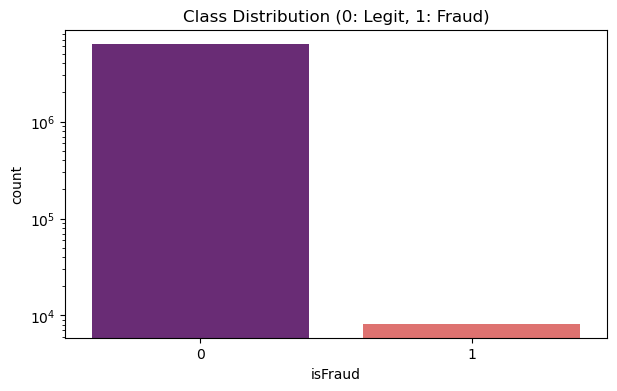

In [25]:
# 1. Class Imbalance Analysis (Updated to avoid FutureWarnings)
plt.figure(figsize=(7,4))

# We assign hue='isFraud' and set legend=False to satisfy the new Seaborn requirements
sns.countplot(data=df, x='isFraud', hue='isFraud', palette='magma', legend=False)

plt.title('Class Distribution (0: Legit, 1: Fraud)')
plt.yscale('log') # Essential for imbalanced data
plt.show()

In [29]:
# 2. Transaction Type Analysis
fraud_by_type = df.groupby('type')['isFraud'].sum()
print("Fraud count per Transaction Type:\n", fraud_by_type)

Fraud count per Transaction Type:
 type
CASH_IN        0
CASH_OUT    4116
DEBIT          0
PAYMENT        0
TRANSFER    4097
Name: isFraud, dtype: int64


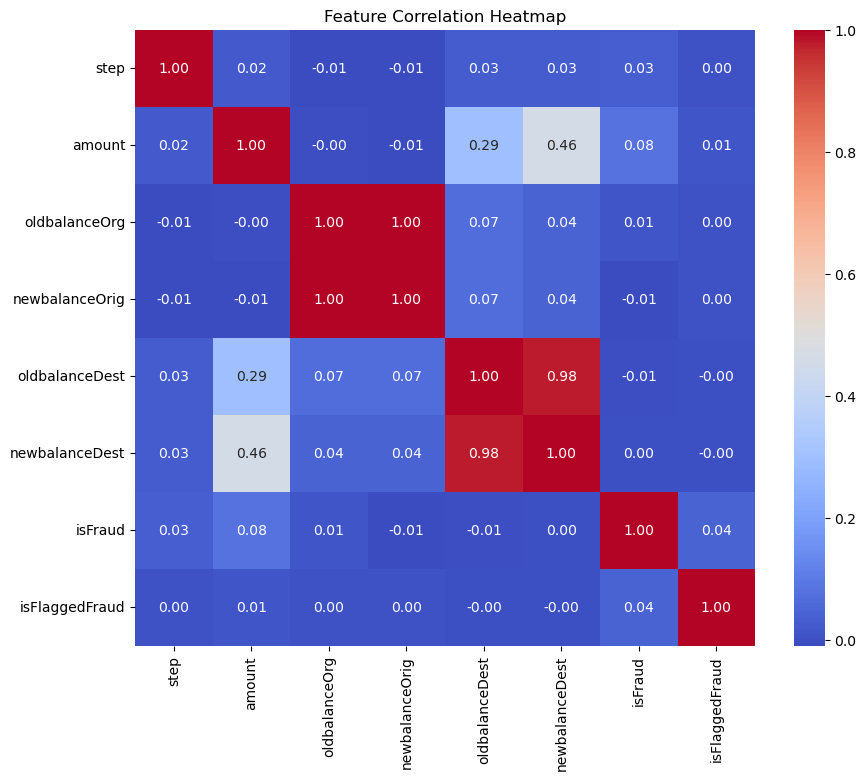

In [31]:
# 3. Correlation Heatmap
plt.figure(figsize=(10,8))
corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Heatmap')
plt.show()

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Create Engineered Features (Logical Levers)
df['errorBalanceOrg'] = df['newbalanceOrig'] + df['amount'] - df['oldbalanceOrg']
df['errorBalanceDest'] = df['oldbalanceDest'] + df['amount'] - df['newbalanceDest']

# 2. One-Hot Encoding for 'type' (Fixes the String-to-Float error)
df_final = pd.get_dummies(df, columns=['type'], drop_first=True)

# 3. Define X and y (Dropping non-predictive identifiers)
X = df_final.drop(['isFraud', 'isFlaggedFraud', 'nameOrig', 'nameDest'], axis=1)
y = df_final['isFraud']

# 4. Train-Test Split (Stratified for imbalance)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# 5. Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [35]:
from sklearn.ensemble import IsolationForest
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, average_precision_score, precision_recall_curve

# --- MODEL A: Isolation Forest (Anomaly Detection) ---
iso_forest = IsolationForest(contamination=0.0012, random_state=42)
iso_forest.fit(X_train_scaled)
iso_preds = iso_forest.predict(X_test_scaled)
iso_preds = [1 if x == -1 else 0 for x in iso_preds]

# --- MODEL B: XGBoost (Weighted Gradient Boosting) ---
# Weighting the model to handle the 1:99 fraud-to-legit ratio
balance_ratio = (y_train == 0).sum() / (y_train == 1).sum()
xgb = XGBClassifier(scale_pos_weight=balance_ratio, n_estimators=100, random_state=42)
xgb.fit(X_train_scaled, y_train)

xgb_preds = xgb.predict(X_test_scaled)
xgb_probs = xgb.predict_proba(X_test_scaled)[:, 1]

--- Isolation Forest Results ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.00      0.00      0.00      1643

    accuracy                           1.00   1272524
   macro avg       0.50      0.50      0.50   1272524
weighted avg       1.00      1.00      1.00   1272524


--- XGBoost Results ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.87      0.99      0.93      1643

    accuracy                           1.00   1272524
   macro avg       0.93      1.00      0.96   1272524
weighted avg       1.00      1.00      1.00   1272524



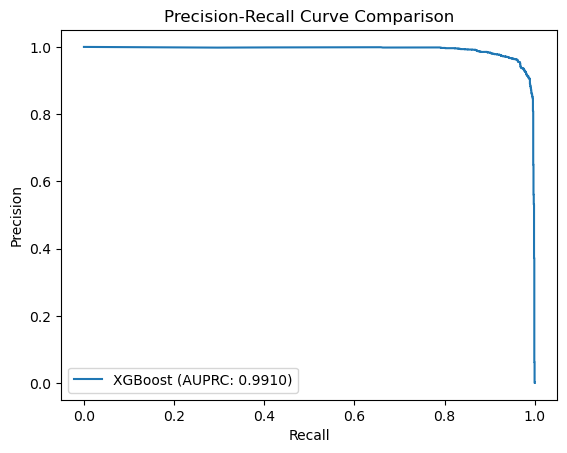

In [37]:
print("--- Isolation Forest Results ---")
print(classification_report(y_test, iso_preds))

print("\n--- XGBoost Results ---")
print(classification_report(y_test, xgb_preds))

# Plotting the Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, xgb_probs)
plt.plot(recall, precision, label=f'XGBoost (AUPRC: {average_precision_score(y_test, xgb_probs):.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve Comparison')
plt.legend()
plt.show()